<a href="https://colab.research.google.com/github/houmirikhadijaencg-eng/21010337--HOUMIRI-Khadija/blob/main/TP_IA_Finance_HOUMIRI_khadija___HLAL_kawtar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PARTIE 1 : STATISTIQUES ET LOI NORMALE EN FINANCE


In [1]:
import numpy as np

# ==============================
# Données des rendements mensuels (%)
# ==============================

rendements_A = np.array([
    1.2, 0.8, -0.5, 1.5, 0.9, 1.1, 0.7, 1.3, 1.0, 0.6, 1.4, 0.8,
    1.1, 0.9, -0.3, 1.2, 1.0, 1.5, 0.8, 1.3, 0.9, 1.1, 1.2, 1.0
])

rendements_B = np.array([
    4.5, -2.1, 6.2, -3.5, 5.8, 7.1, -1.8, 4.9, 3.2, -4.2, 8.5, -2.7,
    5.1, 6.8, -3.1, 7.3, 4.5, -2.9, 6.7, 5.3, -3.8, 7.9, 4.2, 5.5
])

# ==============================
# Fonction de calcul des stats
# ==============================

def stats_portefeuille(rendements):
    rendements_decimal = rendements / 100  # conversion en décimal

    moyenne_mensuelle = np.mean(rendements)
    ecart_type_mensuel = np.std(rendements, ddof=1)
    mediane = np.median(rendements)

    rendement_annuel = (1 + moyenne_mensuelle / 100) ** 12 - 1
    volatilite_annuelle = ecart_type_mensuel * np.sqrt(12)

    return (
        moyenne_mensuelle,
        ecart_type_mensuel,
        mediane,
        rendement_annuel * 100,
        volatilite_annuelle
    )

# ==============================
# Calculs
# ==============================

stats_A = stats_portefeuille(rendements_A)
stats_B = stats_portefeuille(rendements_B)

# ==============================
# Affichage formaté
# ==============================

def afficher_stats(nom, stats):
    print(f"\nPORTEFEUILLE {nom}")
    print(f"• Rendement mensuel moyen : {stats[0]:.2f}%")
    print(f"• Écart-type mensuel : {stats[1]:.2f}%")
    print(f"• Médiane : {stats[2]:.2f}%")
    print(f"• Rendement annualisé : {stats[3]:.2f}%")
    print(f"• Volatilité annualisée : {stats[4]:.2f}%")

afficher_stats("A (Conservative)", stats_A)
afficher_stats("B (Agressif)", stats_B)



PORTEFEUILLE A (Conservative)
• Rendement mensuel moyen : 0.94%
• Écart-type mensuel : 0.48%
• Médiane : 1.00%
• Rendement annualisé : 11.85%
• Volatilité annualisée : 1.65%

PORTEFEUILLE B (Agressif)
• Rendement mensuel moyen : 2.89%
• Écart-type mensuel : 4.45%
• Médiane : 4.70%
• Rendement annualisé : 40.79%
• Volatilité annualisée : 15.41%


/tmp/ipython-input-86972328.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


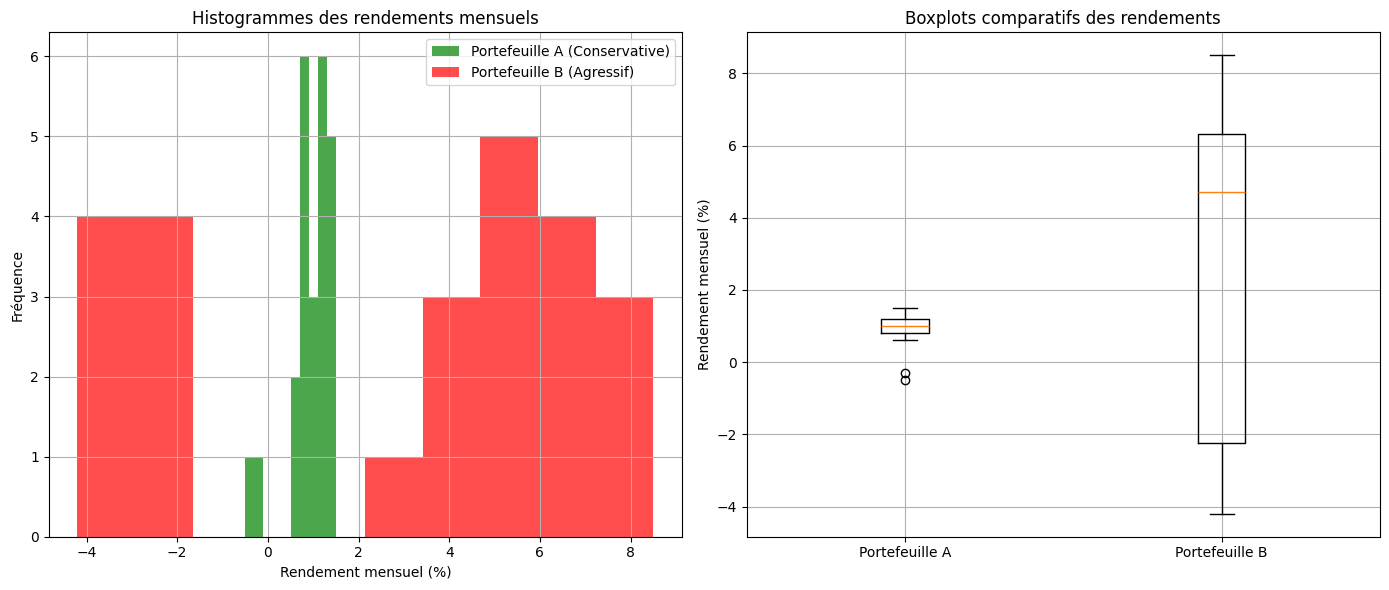

In [3]:
import matplotlib.pyplot as plt

# ==============================
# Création de la figure et des subplots
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==============================
# Subplot 1 : Histogrammes superposés
# ==============================

axes[0].hist(rendements_A, bins=10, alpha=0.7, label="Portefeuille A (Conservative)", color="green")
axes[0].hist(rendements_B, bins=10, alpha=0.7, label="Portefeuille B (Agressif)", color="red")

axes[0].set_title("Histogrammes des rendements mensuels")
axes[0].set_xlabel("Rendement mensuel (%)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()
axes[0].grid(True)

# ==============================
# Subplot 2 : Boxplots comparatifs
# ==============================

axes[1].boxplot(
    [rendements_A, rendements_B],
    labels=["Portefeuille A", "Portefeuille B"],
    showfliers=True
)

axes[1].set_title("Boxplots comparatifs des rendements")
axes[1].set_ylabel("Rendement mensuel (%)")
axes[1].grid(True)

# ==============================
# Affichage final
# ==============================

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
from scipy.stats import shapiro, norm

# ==============================
# Paramètres supplémentaires nécessaires
# ==============================
z_95 = norm.ppf(0.95) # Z-score pour un niveau de confiance de 95%
capital = 500000     # Capital investi en euros (exemple)
seuil_client = 50000 # Seuil de perte maximale tolérée par le client en euros

# ==============================
# Fonction VaR + normalité
# ==============================

def calcul_var(rendements, nom):
    mu_m = np.mean(rendements)
    sigma_m = np.std(rendements, ddof=1)

    var_mensuelle = mu_m - z_95 * sigma_m

    mu_annuel = (1 + mu_m / 100) ** 12 - 1
    sigma_annuel = sigma_m * np.sqrt(12)

    var_annuelle = mu_annuel * 100 - z_95 * sigma_annuel
    perte_euros = abs(var_annuelle / 100) * capital

    stat, p_value = shapiro(rendements)

    print(f"\n==============================")
    print(f"PORTEFEUILLE {nom}")
    print(f"==============================")
    print(f"VaR 95% mensuelle : {var_mensuelle:.2f}%")
    print(f"VaR 95% annuelle : {var_annuelle:.2f}%")
    print(f"Perte potentielle annuelle (€) : {perte_euros:,.0f} €")

    if perte_euros <= seuil_client:
        print("✔ Contrainte client RESPECTÉE (≤ 50,000 €)")
    else:
        print("✘ Contrainte client NON RESPECTÉE (> 50,000 €)")

    print(f"\nTest Shapiro-Wilk :")
    print(f"• Statistique : {stat:.3f}")
    print(f"• p-value : {p_value:.4f}")

    if p_value > 0.05:
        print("✔ Hypothèse de normalité ACCEPTÉE")
    else:
        print("✘ Hypothèse de normalité REJETÉE")

# ==============================
# Exécution
# ==============================

calcul_var(rendements_A, "A (Conservative)")
calcul_var(rendements_B, "B (Agressif)")


PORTEFEUILLE A (Conservative)
VaR 95% mensuelle : 0.15%
VaR 95% annuelle : 9.13%
Perte potentielle annuelle (€) : 45,649 €
✔ Contrainte client RESPECTÉE (≤ 50,000 €)

Test Shapiro-Wilk :
• Statistique : 0.803
• p-value : 0.0003
✘ Hypothèse de normalité REJETÉE

PORTEFEUILLE B (Agressif)
VaR 95% mensuelle : -4.42%
VaR 95% annuelle : 15.45%
Perte potentielle annuelle (€) : 77,231 €
✘ Contrainte client NON RESPECTÉE (> 50,000 €)

Test Shapiro-Wilk :
• Statistique : 0.837
• p-value : 0.0012
✘ Hypothèse de normalité REJETÉE


In [7]:
import numpy as np
from scipy.stats import shapiro, norm

# ==============================
# Paramètres supplémentaires nécessaires (copiés pour assurer la disponibilité si le cell précédent n'a pas été exécuté ou a été modifié)
# ==============================
z_95 = norm.ppf(0.95) # Z-score pour un niveau de confiance de 95%
capital = 500000     # Capital investi en euros (exemple)
seuil_client = 50000 # Seuil de perte maximale tolérée par le client en euros
rf = 0.02            # Taux sans risque (ex: 2%)
seuil_var = seuil_client # Utilisation du seuil client pour la contrainte VaR

# ==============================
# Fonction Sharpe + critères
# ==============================

def analyse_sharpe(rendements, nom):
    mu_m = np.mean(rendements)
    sigma_m = np.std(rendements, ddof=1)

    mu_annuel = (1 + mu_m / 100) ** 12 - 1
    sigma_annuel = sigma_m * np.sqrt(12) / 100

    sharpe = (mu_annuel - rf) / sigma_annuel

    var_annuelle = mu_annuel * 100 - z_95 * (sigma_m * np.sqrt(12))
    perte_euros = abs(var_annuelle / 100) * capital

    stat, p_value = shapiro(rendements)

    print(f"\n==============================")
    print(f"PORTEFEUILLE {nom}")
    print(f"==============================")
    print(f"Rendement annualisé : {mu_annuel*100:.2f}%")
    print(f"Volatilité annualisée : {sigma_annuel*100:.2f}%")
    print(f"Ratio de Sharpe : {sharpe:.2f}")
    print(f"VaR annuelle (€) : {perte_euros:,.0f} €")
    print(f"p-value Shapiro-Wilk : {p_value:.4f}")

    respecte_var = perte_euros <= seuil_var
    normalite = p_value > 0.05

    return {
        "nom": nom,
        "sharpe": sharpe,
        "var_ok": respecte_var,
        "normalite": normalite
    }

# ==============================
# Analyse des deux portefeuilles
# ==============================

result_A = analyse_sharpe(rendements_A, "A (Conservative)")
result_B = analyse_sharpe(rendements_B, "B (Agressif)")

# ==============================
# Recommandation finale
# ==============================

print("\n==============================")
print("RECOMMANDATION CLIENT")
print("==============================")

candidats = []

for r in [result_A, result_B]:
    if r["var_ok"] and r["normalite"]:
        candidats.append(r)

if candidats:
    meilleur = max(candidats, key=lambda x: x["sharpe"])
    print(f"✔ Portefeuille recommandé : {meilleur['nom']}")
    print(f"✔ Sharpe maximum sous contraintes : {meilleur['sharpe']:.2f}")
else:
    print("✘ Aucun portefeuille ne respecte simultanément toutes les contraintes")


PORTEFEUILLE A (Conservative)
Rendement annualisé : 11.85%
Volatilité annualisée : 1.65%
Ratio de Sharpe : 5.96
VaR annuelle (€) : 45,649 €
p-value Shapiro-Wilk : 0.0003

PORTEFEUILLE B (Agressif)
Rendement annualisé : 40.79%
Volatilité annualisée : 15.41%
Ratio de Sharpe : 2.52
VaR annuelle (€) : 77,231 €
p-value Shapiro-Wilk : 0.0012

RECOMMANDATION CLIENT
✘ Aucun portefeuille ne respecte simultanément toutes les contraintes


PARTIE 2 — THÉORÈME DE BAYES ET SCORING CRÉDIT


In [8]:
import numpy as np

# ==============================
# Données initiales
# ==============================

# Prior segment Standard
P_defaut = 0.05
P_non_defaut = 1 - P_defaut

# Likelihoods (Retard paiement)
P_retard_given_defaut = 0.80
P_retard_given_non_defaut = 0.10

# ==============================
# Calcul Bayes
# ==============================

# Numérateur
numerateur = P_retard_given_defaut * P_defaut

# Dénominateur
denominateur = (P_retard_given_defaut * P_defaut) + \
               (P_retard_given_non_defaut * P_non_defaut)

# Posterior
P_defaut_given_retard = numerateur / denominateur

# ==============================
# Facteur multiplicatif
# ==============================

facteur_risque = P_defaut_given_retard / P_defaut

# ==============================
# Affichage détaillé
# ==============================

print("=======================================")
print("CALCUL BAYES — SEGMENT STANDARD")
print("=======================================\n")

print(f"Prior P(Défaut) : {P_defaut*100:.2f}%")
print(f"P(Retard | Défaut) : {P_retard_given_defaut*100:.2f}%")
print(f"P(Retard | Non-défaut) : {P_retard_given_non_defaut*100:.2f}%\n")

print("Formule :")
print("P(D|R) = [P(R|D)*P(D)] / [P(R|D)*P(D) + P(R|¬D)*P(¬D)]\n")

print(f"Numérateur : {numerateur:.4f}")
print(f"Dénominateur : {denominateur:.4f}\n")

print(f"Posterior P(Défaut | Retard) : {P_defaut_given_retard*100:.2f}%")
print(f"Facteur multiplicatif du risque : x{facteur_risque:.2f}")

# ==============================
# Décision métier
# ==============================

print("\n=======================================")
print("RECOMMANDATION MÉTIER")
print("=======================================")

if P_defaut_given_retard < 0.08:
    decision = "Maintien conditions normales"
elif P_defaut_given_retard < 0.15:
    decision = "Surveillance renforcée"
else:
    decision = "Restriction crédit / revue dossier"

print(f"Décision recommandée : {decision}")


CALCUL BAYES — SEGMENT STANDARD

Prior P(Défaut) : 5.00%
P(Retard | Défaut) : 80.00%
P(Retard | Non-défaut) : 10.00%

Formule :
P(D|R) = [P(R|D)*P(D)] / [P(R|D)*P(D) + P(R|¬D)*P(¬D)]

Numérateur : 0.0400
Dénominateur : 0.1350

Posterior P(Défaut | Retard) : 29.63%
Facteur multiplicatif du risque : x5.93

RECOMMANDATION MÉTIER
Décision recommandée : Restriction crédit / revue dossier


In [9]:
def bayes_update(prior, likelihood_pos, likelihood_neg):
    """
    Calcule la probabilité postérieure P(Positive | Evidence)
    à l'aide du théorème de Bayes.

    Paramètres
    ----------
    prior : float
        Probabilité a priori P(Positive)
    likelihood_pos : float
        P(Evidence | Positive)
    likelihood_neg : float
        P(Evidence | Negative)

    Retour
    ------
    float
        Probabilité postérieure P(Positive | Evidence)

    Exemple
    -------
    >>> bayes_update(0.05, 0.80, 0.10)
    0.2962962962962963
    """
    numerator = likelihood_pos * prior
    denominator = numerator + likelihood_neg * (1 - prior)
    return numerator / denominator
prior_risque = 0.15

events = {
    "Retard paiement": (0.80, 0.10),
    "Découvert >500€": (0.65, 0.15),
    "Crédit refusé ailleurs": (0.55, 0.08)
}

print("Client Segment Risque — Mise à jour Bayes\n")

for event, (p_def, p_nondef) in events.items():
    posterior = bayes_update(prior_risque, p_def, p_nondef)
    print(f"{event} → P(Défaut|Événement) = {posterior*100:.2f}%")


Client Segment Risque — Mise à jour Bayes

Retard paiement → P(Défaut|Événement) = 58.54%
Découvert >500€ → P(Défaut|Événement) = 43.33%
Crédit refusé ailleurs → P(Défaut|Événement) = 54.82%


PARTIE 3


In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 2000
age = np.random.randint(25, 66, n_samples)
salaire = np.random.normal(50000, 20000, n_samples).clip(20000, 120000)
anciennete_emploi = np.random.exponential(5, n_samples).clip(0, 30)

dette_totale = np.random.normal(25000, 15000, n_samples).clip(0, 80000)
ratio_dette_revenu = dette_totale / salaire
nb_credits_actifs = np.random.poisson(1.5, n_samples).clip(0, 5)
historique_retards = np.random.poisson(2, n_samples).clip(0, 10)
score_credit = np.random.normal(650, 100, n_samples).clip(300, 850)

# Target : Défaut si combo risque élevé
defaut_proba = (
    0.05 + # Baseline 5%
    0.15 * (ratio_dette_revenu > 0.5) +
    0.10 * (historique_retards > 3) +
    0.08 * (score_credit < 600) +
    0.05 * (nb_credits_actifs > 2)
).clip(0, 0.85)

defaut = (np.random.rand(n_samples) < defaut_proba).astype(int)

df = pd.DataFrame({
    'age': age,
    'salaire': salaire,
    'anciennete_emploi': anciennete_emploi,
    'dette_totale': dette_totale,
    'ratio_dette_revenu': ratio_dette_revenu,
    'nb_credits_actifs': nb_credits_actifs,
    'historique_retards': historique_retards,
    'score_credit_bureau': score_credit,
    'defaut': defaut
})

df.to_csv('credit_data.csv', index=False)
print(f"Dataset généré : {len(df)} clients, taux défaut {defaut.mean():.1%}")

Dataset généré : 2000 clients, taux défaut 16.7%


In [15]:
import numpy as np
import pandas as pd

n = 2000 # Define the number of samples

# Génération des variables explicatives
df = pd.DataFrame({
    "age": np.random.randint(21, 70, n),
    "revenu_mensuel": np.random.normal(5000, 1500, n),
    "ratio_dette_revenu": np.random.beta(2, 5, n),
    "historique_retards": np.random.poisson(1.2, n),
    "decouvert": np.random.binomial(1, 0.25, n)
})

# Génération de la variable cible (défaut)
logit = (
    -3
    + 4 * df["ratio_dette_revenu"]
    + 0.6 * df["historique_retards"]
    + 1.2 * df["decouvert"]
)

proba_defaut = 1 / (1 + np.exp(-logit))
df["defaut"] = np.random.binomial(1, proba_defaut)

   age  revenu_mensuel  ratio_dette_revenu  historique_retards  decouvert  \
0   26     5407.263933            0.210116                   1          0   
1   59     4639.321782            0.579239                   3          1   
2   61     5218.391325            0.049018                   1          1   
3   51     4412.883001            0.130568                   3          0   
4   55     4595.299509            0.113744                   3          1   

   defaut  
0       0  
1       1  
2       0  
3       1  
4       0  
               age  revenu_mensuel  ratio_dette_revenu  historique_retards  \
count  2000.000000     2000.000000         2000.000000          2000.00000   
mean     44.589000     4972.035343            0.283102             1.19100   
std      14.041712     1487.527143            0.157562             1.06117   
min      21.000000      204.645823            0.005401             0.00000   
25%      32.000000     3951.530737            0.160952             0.00000 

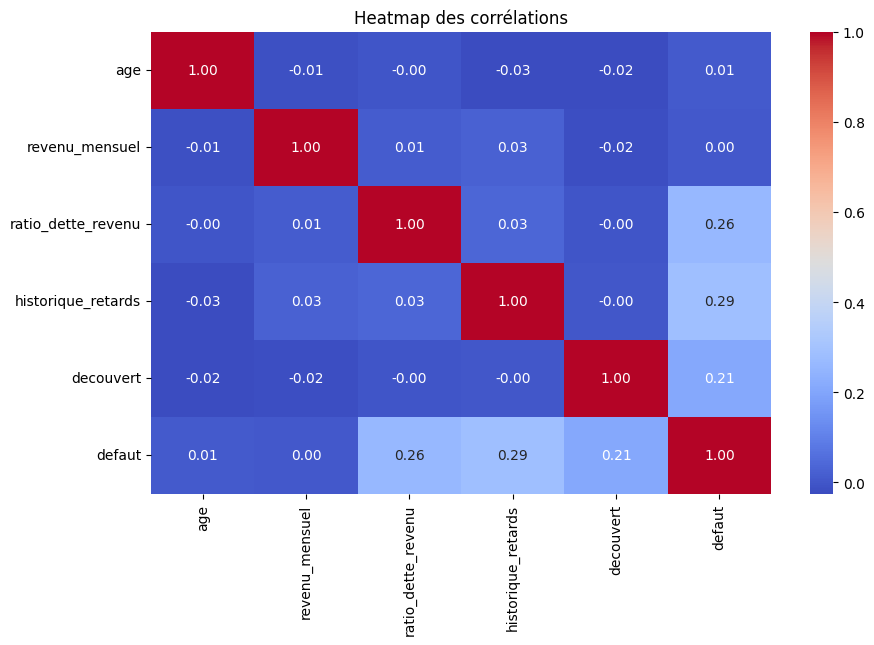

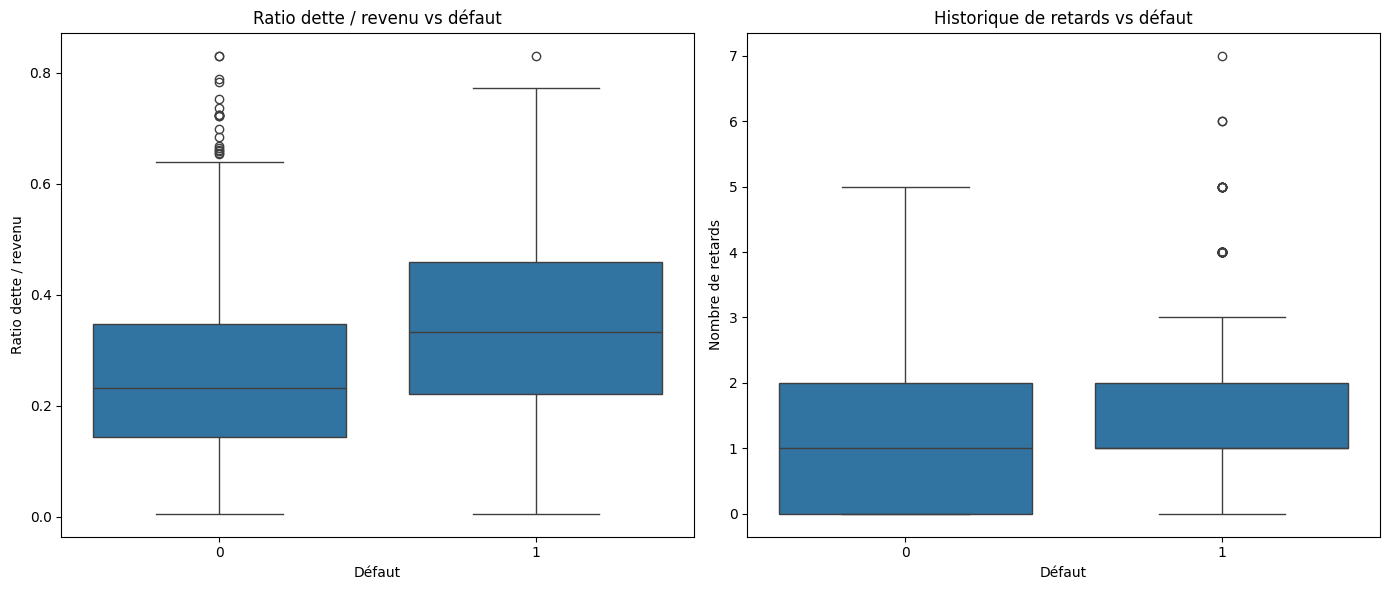

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5 premières lignes
print(df.head())

# Statistiques descriptives
print(df.describe())
taux_defaut = df["defaut"].mean()
print(f"Taux de défaut : {taux_defaut*100:.2f}%")
print("Distribution de la variable défaut :")
print(df["defaut"].value_counts())
correlation_defaut = df.corr(numeric_only=True)["defaut"].sort_values()
print("Corrélation des variables avec le défaut :")
print(correlation_defaut)
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Heatmap des corrélations")
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x="defaut", y="ratio_dette_revenu", data=df, ax=axes[0])
axes[0].set_title("Ratio dette / revenu vs défaut")
axes[0].set_xlabel("Défaut")
axes[0].set_ylabel("Ratio dette / revenu")

sns.boxplot(x="defaut", y="historique_retards", data=df, ax=axes[1])
axes[1].set_title("Historique de retards vs défaut")
axes[1].set_xlabel("Défaut")
axes[1].set_ylabel("Nombre de retards")

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ==============================
# Séparation features / target
# ==============================

X = df.drop("defaut", axis=1)
y = df["defaut"]

# ==============================
# Split train / test (70/30)
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# ==============================
# Normalisation
# ==============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)

print("\nDistribution classes TRAIN (%)")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribution classes TEST (%)")
print(y_test.value_counts(normalize=True) * 100)


Taille train : (1400, 5)
Taille test : (600, 5)

Distribution classes TRAIN (%)
defaut
0    67.928571
1    32.071429
Name: proportion, dtype: float64

Distribution classes TEST (%)
defaut
0    68.0
1    32.0
Name: proportion, dtype: float64


In [20]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, recall_score, precision_score

K_values = [1, 3, 5, 7, 9, 11, 15, 20, 25, 30]
results = []

for k in K_values:
    model = KNeighborsClassifier(n_neighbors=k)

    auc_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring="roc_auc"
    )

    recall_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring=make_scorer(recall_score)
    )

    precision_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring=make_scorer(precision_score)
    )

    results.append({
        "K": k,
        "AUC_mean": auc_scores.mean(),
        "AUC_std": auc_scores.std(),
        "Recall_mean": recall_scores.mean(),
        "Precision_mean": precision_scores.mean()
    })

results_df = pd.DataFrame(results)
print(results_df)


    K  AUC_mean   AUC_std  Recall_mean  Precision_mean
0   1  0.618240  0.026553     0.485668        0.479824
1   3  0.662801  0.023309     0.414282        0.503001
2   5  0.681385  0.025772     0.405443        0.545327
3   7  0.696805  0.030384     0.394282        0.543371
4   9  0.708887  0.028896     0.369763        0.564984
5  11  0.709783  0.023954     0.371935        0.608959
6  15  0.713623  0.014775     0.354082        0.597846
7  20  0.727574  0.018082     0.291810        0.619205
8  25  0.729981  0.014144     0.327491        0.637867
9  30  0.734323  0.014273     0.287316        0.642733


K optimal (AUC max) : 30


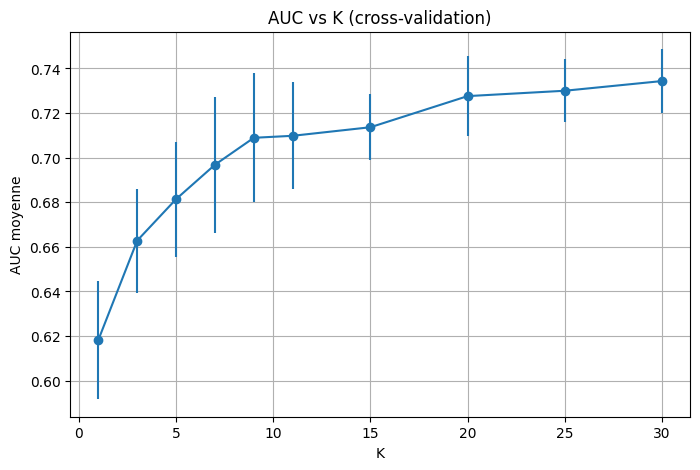

In [21]:
K_optimal = results_df.loc[results_df["AUC_mean"].idxmax(), "K"]
print(f"K optimal (AUC max) : {K_optimal}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.errorbar(
    results_df["K"],
    results_df["AUC_mean"],
    yerr=results_df["AUC_std"],
    fmt="-o"
)
plt.xlabel("K")
plt.ylabel("AUC moyenne")
plt.title("AUC vs K (cross-validation)")
plt.grid(True)
plt.show()


In [22]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

knn_final = KNeighborsClassifier(n_neighbors=K_optimal)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)
y_pred_proba = knn_final.predict_proba(X_test_scaled)[:, 1]


In [23]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

specificity = TN / (TN + FP)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("AUC-ROC :", roc_auc_score(y_test, y_pred_proba))
print("Specificity :", specificity)


Accuracy : 0.725
Precision : 0.6483516483516484
Recall : 0.3072916666666667
F1-score : 0.4169611307420495
AUC-ROC : 0.7419321895424836
Specificity : 0.9215686274509803


              precision    recall  f1-score   support

           0       0.74      0.92      0.82       408
           1       0.65      0.31      0.42       192

    accuracy                           0.72       600
   macro avg       0.69      0.61      0.62       600
weighted avg       0.71      0.72      0.69       600



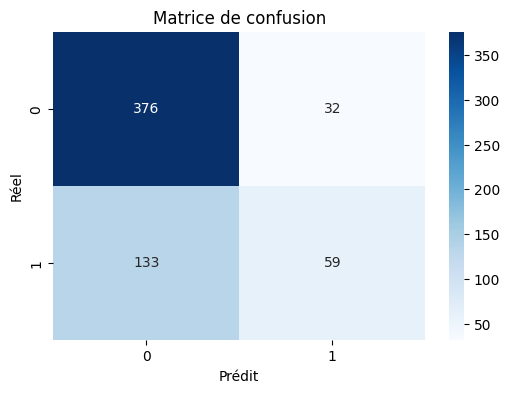

In [24]:
import seaborn as sns

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d", cmap="Blues"
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


In [25]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Indice de Youden
youden = tpr - fpr
idx_opt = np.argmax(youden)
seuil_opt = thresholds[idx_opt]


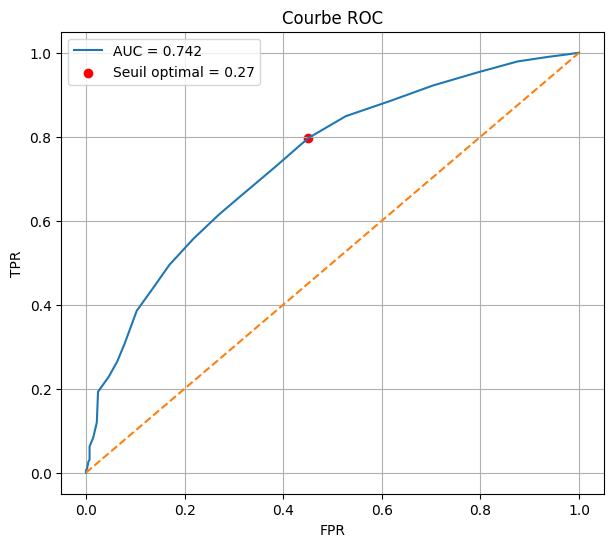

In [26]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.scatter(fpr[idx_opt], tpr[idx_opt], color="red", label=f"Seuil optimal = {seuil_opt:.2f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Courbe ROC")
plt.legend()
plt.grid()
plt.show()


In [27]:
seuils = [0.3, 0.5, 0.7]

for s in seuils:
    y_pred_s = (y_pred_proba >= s).astype(int)
    print(f"\nSeuil {s}")
    print("Precision :", precision_score(y_test, y_pred_s))
    print("Recall :", recall_score(y_test, y_pred_s))
    print("F1 :", f1_score(y_test, y_pred_s))



Seuil 0.3
Precision : 0.4713804713804714
Recall : 0.7291666666666666
F1 : 0.5725971370143149

Seuil 0.5
Precision : 0.6379310344827587
Recall : 0.3854166666666667
F1 : 0.4805194805194805

Seuil 0.7
Precision : 0.7272727272727273
Recall : 0.08333333333333333
F1 : 0.14953271028037382


In [28]:
def calcul_roi(y_true, y_pred):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    gains = TP * 15_000
    couts_fp = FP * (500 + 1_200)
    pertes_fn = FN * 15_000

    roi = gains - couts_fp - pertes_fn
    return roi

for s in seuils:
    y_pred_s = (y_pred_proba >= s).astype(int)
    roi = calcul_roi(y_test, y_pred_s)
    print(f"ROI seuil {s} : {roi:,.0f} €")


ROI seuil 0.3 : 1,053,100 €
ROI seuil 0.5 : -731,400 €
ROI seuil 0.7 : -2,410,200 €
